#### This is the show the resumebility of graph executions if there is any interruption

- We will create a muanual keboard interruption here

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from time import sleep
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
class State(TypedDict):
    input:str
    node_1: str
    node_2: str
    node_3: str

In [4]:
def node_1(state:State) -> State:
    print("Node 1 execution completed")
    return {"node_1": "done"}

def node_2(state:State) -> State:
    print("node_2 execution started and haulted for 30s")
    sleep(30)
    print("node_2 execution completed")
    return {"node_2": 'done'}

def node_3(state:State) -> State:
    print("node_3 execution completed")
    return {"node_3": "done"}

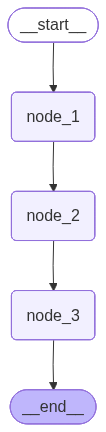

In [14]:
graph = StateGraph(State)

## Add Nodes
graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)
graph.add_node("node_3", node_3)

## Add Edeges
graph.add_edge(START, 'node_1')
graph.add_edge('node_1','node_2')
graph.add_edge('node_2', 'node_3')
graph.add_edge('node_3', END)

checkpoint = InMemorySaver()
workflow = graph.compile(checkpointer=checkpoint)
workflow

In [16]:
congig = {"configurable":{"thread_id": "thread_1"}}

In [17]:
try:
    initial_state = {'input': "start"}
    final_state = workflow.invoke(initial_state, config=congig)
    print(final_state)
except KeyboardInterrupt:
    print("Keyboard interrupt detected. Execution Stoped")

Node 1 execution completed
node_2 execution started and haulted for 30s
Keyboard interrupt detected. Execution Stoped


##### Here the execution stoped, now lets see the state and the state history of whatever got executed 

In [18]:
workflow.get_state(config=congig)

StateSnapshot(values={'input': 'start', 'node_1': 'done'}, next=('node_2',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d02-0bb9-6e4b-8001-100842a3c7c7'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-14T09:05:02.522092+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d02-0bb3-640a-8000-f851e1576b46'}}, tasks=(PregelTask(id='b9e6bb5e-974d-2f01-50ea-2a5ea4d6f992', name='node_2', path=('__pregel_pull', 'node_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

##### see the `next=('node_2',)` the status is not done (see same for `node_1` it's done)

In [19]:
list(workflow.get_state_history(config=congig))

[StateSnapshot(values={'input': 'start', 'node_1': 'done'}, next=('node_2',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d02-0bb9-6e4b-8001-100842a3c7c7'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-14T09:05:02.522092+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d02-0bb3-640a-8000-f851e1576b46'}}, tasks=(PregelTask(id='b9e6bb5e-974d-2f01-50ea-2a5ea4d6f992', name='node_2', path=('__pregel_pull', 'node_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('node_1',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d02-0bb3-640a-8000-f851e1576b46'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-14T09:05:02.519362+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'c

##### In the top line the next node execution is set to node_2 (`next=('node_2',),`). That means the next time it will start execution it will resume from node_2

##### To make that happen we have to pass None as initial state when we invoke workflow

In [20]:
workflow.invoke(None, config=congig)

node_2 execution started and haulted for 30s
node_2 execution completed
node_3 execution completed


{'input': 'start', 'node_1': 'done', 'node_2': 'done', 'node_3': 'done'}

##### See, it directly started exection from node_2

In [21]:
workflow.get_state(config=congig)

StateSnapshot(values={'input': 'start', 'node_1': 'done', 'node_2': 'done', 'node_3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d10-f72a-6b4f-8003-9094ef4841be'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-06-14T09:11:43.019478+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d10-f726-63d7-8002-d71717767094'}}, tasks=(), interrupts=())

In [22]:
list(workflow.get_state_history(config=congig))

[StateSnapshot(values={'input': 'start', 'node_1': 'done', 'node_2': 'done', 'node_3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d10-f72a-6b4f-8003-9094ef4841be'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-06-14T09:11:43.019478+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d10-f726-63d7-8002-d71717767094'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'node_1': 'done', 'node_2': 'done'}, next=('node_3',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d10-f726-63d7-8002-d71717767094'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-14T09:11:43.017642+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f167d02-0bb9-6e4b-8001-100842a3c7c7'}}, tasks=(PregelTask(id='7081458d-b996